<h1 style="text-align:center; font-size:40px; font-weight:bold;">
 Housing Price Prediction using Data Analytics and Machine Learning
</h1>

---


<h2 style="font-weight:bold;">IMPORTING REQUIRED LIBRARIES</h2>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn import metrics

<h2 style="font-weight:bold;">LOADING THE DATASET</h2>

In [2]:
df=pd.read_csv(r"C:\Users\HP\Downloads\house_price_regression_dataset.csv")
print(df.head(10))

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   
5            3944             5              3        1990  2.475930   
6            3671             1              2        2012  4.911960   
7            3419             1              1        1972  2.805281   
8             630             3              3        1997  1.014286   
9            2185             4              2        1981  3.941604   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+

<h2 style="font-weight:bold;">DATA UNDERSTANDING AND CLEANING</h2>

In [3]:
df.shape 

(1000, 8)

In [4]:
df.columns 

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [6]:
df.describe() 

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [7]:
df.isnull().sum() 

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

<h2 style="font-weight:bold;">EXPLORATORY DATA ANALYSIS (EDA)</h2>

**1:** What is the overall distribution of house prices in the dataset? Are the prices normally distributed or skewed?

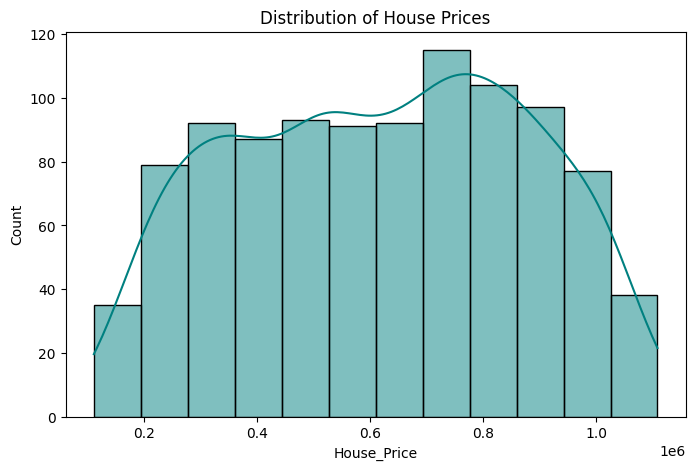

In [9]:
plt.figure(figsize=(8, 5)) 
sns.histplot(df['House_Price'], kde=True, color='teal') 
plt.title('Distribution of House Prices') 
plt.show()

Most houses fall in a moderate price range, while a few houses have very high prices. This indicates the presence of high-value properties (outliers).

**2:** How does the size of a house (square footage) influence its price? Is there a positive correlation between them?

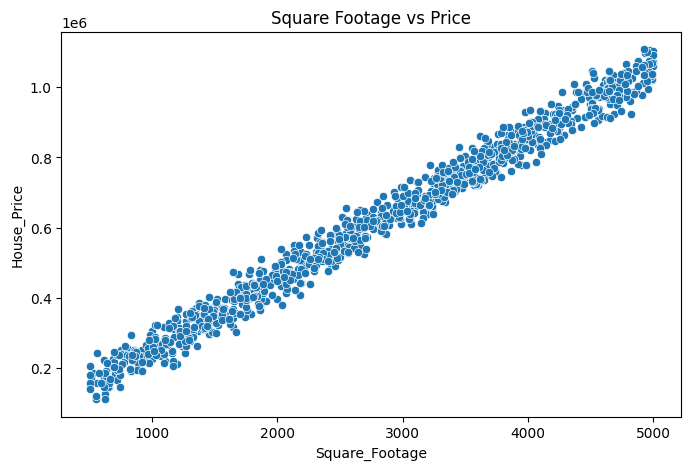

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Square_Footage', y='House_Price', data=df)
plt.title('Square Footage vs Price')
plt.show()

As the size of the house increases, the price also increases. Larger houses tend to be more expensive.

**3:** How does neighborhood quality affect house prices? Do better neighborhoods have significantly higher prices?

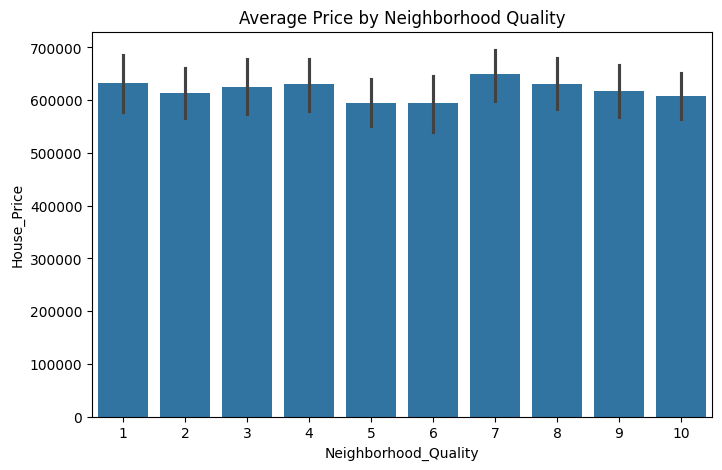

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Neighborhood_Quality', y='House_Price', data=df)
plt.title('Average Price by Neighborhood Quality')
plt.show()

Houses in high-quality neighborhoods have significantly higher average prices, showing that location is a key factor.

**4:** Does increasing the number of bedrooms lead to higher house prices? Is there a noticeable trend or variation?

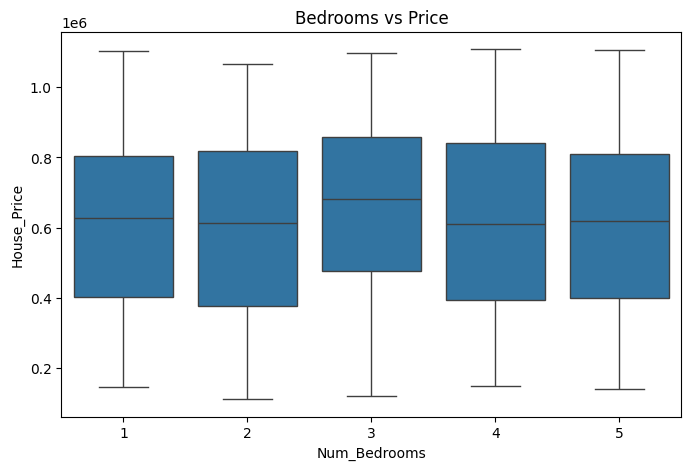

In [12]:
plt.figure(figsize=(8, 5)) 
sns.boxplot(x='Num_Bedrooms', y='House_Price', data=df) 
plt.title('Bedrooms vs Price') 
plt.show()

Although prices rise with more bedrooms, there is variation, meaning other features also influence price.

**5:** What are the relationships between all numerical variables in the dataset? Which features have the strongest correlation with house price?

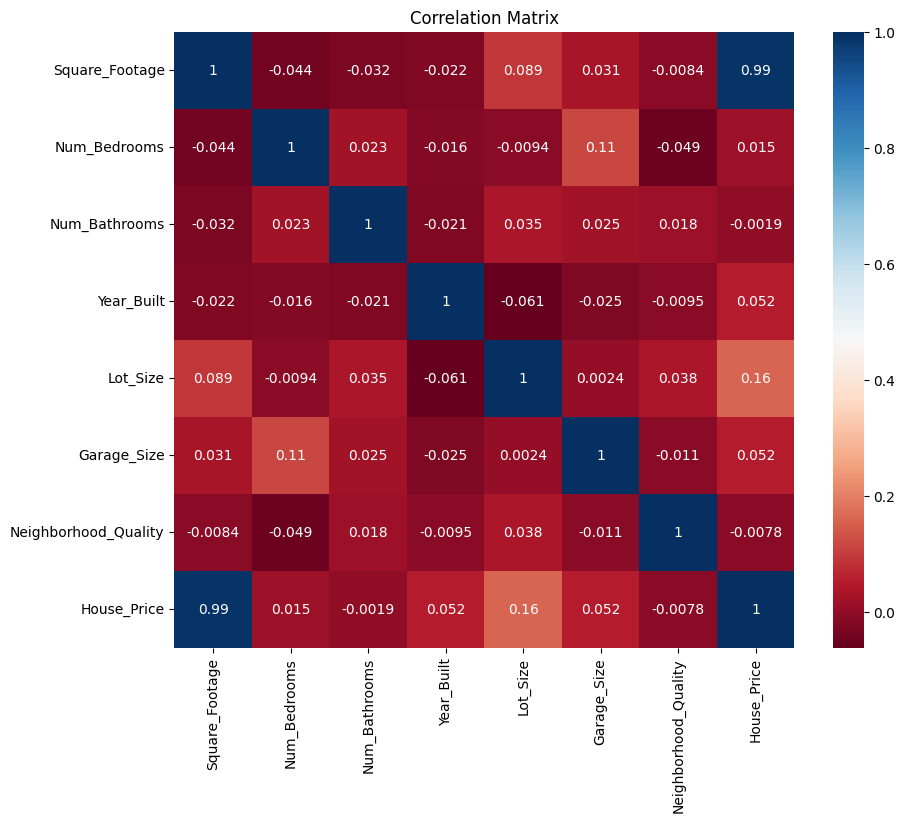

In [13]:
plt.figure(figsize=(10, 8)) 
sns.heatmap(df.corr(), annot=True, cmap='RdBu') 
plt.title('Correlation Matrix') 
plt.show()

These features are the most important factors affecting house price, while others have weaker influence.

**6:** Is there a relationship between lot size and house price? Does a larger lot size lead to higher property value?

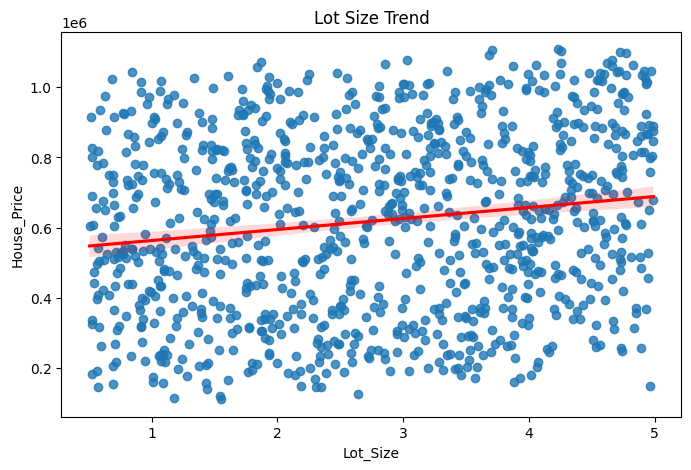

In [14]:
plt.figure(figsize=(8, 5)) 
sns.regplot(x='Lot_Size', y='House_Price', data=df, line_kws={"color":"red"}) 
plt.title('Lot Size Trend') 
plt.show()

Larger land size generally increases property value, but the effect is moderate compared to house size.

**7:** How does the year a house was built influence its price? Do newer houses tend to be more expensive than older ones?

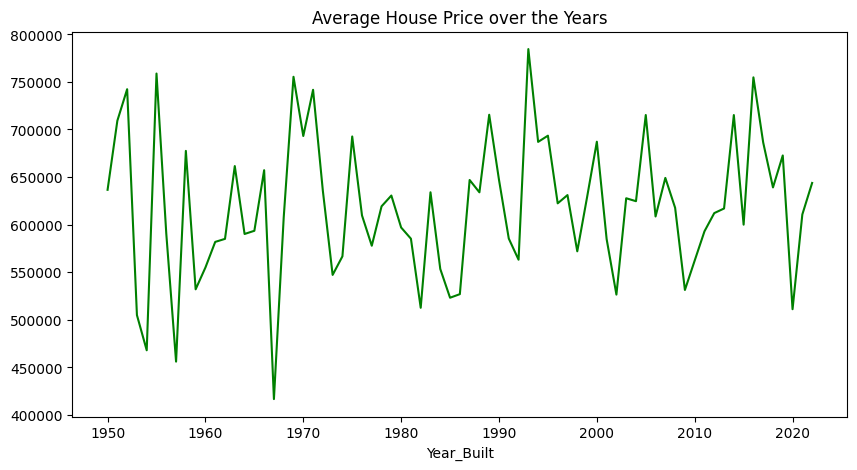

In [15]:
plt.figure(figsize=(10, 5)) 
df.groupby('Year_Built')['House_Price'].mean().plot(color='green') 
plt.title('Average House Price over the Years')
plt.show()

Modern houses are more expensive due to better design, materials, and facilities.

**8:** What is the distribution of garage sizes in the dataset? Which garage size is most common?

C:\Users\HP\AppData\Local\Temp\ipykernel_12140\2586093987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Garage_Size', data=df, palette='viridis')


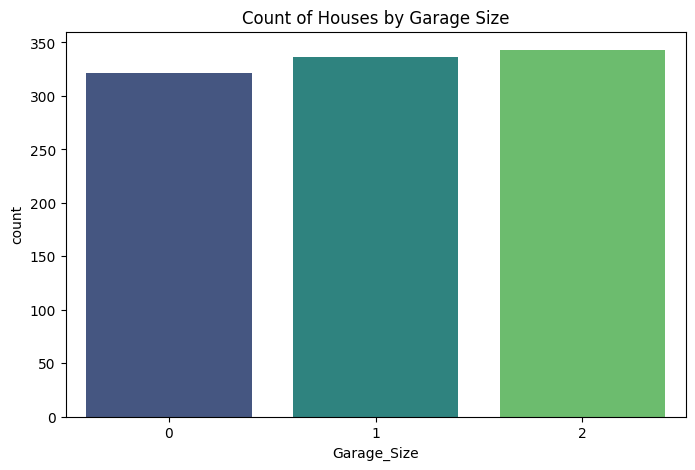

In [16]:
plt.figure(figsize=(8, 5)) 
sns.countplot(x='Garage_Size', data=df, palette='viridis') 
plt.title('Count of Houses by Garage Size') 
plt.show()

Garage sizes like 1 or 2 cars are most common, while very large garages are rare.

**9:** Are there any outliers in the square footage feature? Do some houses have unusually large or small sizes?

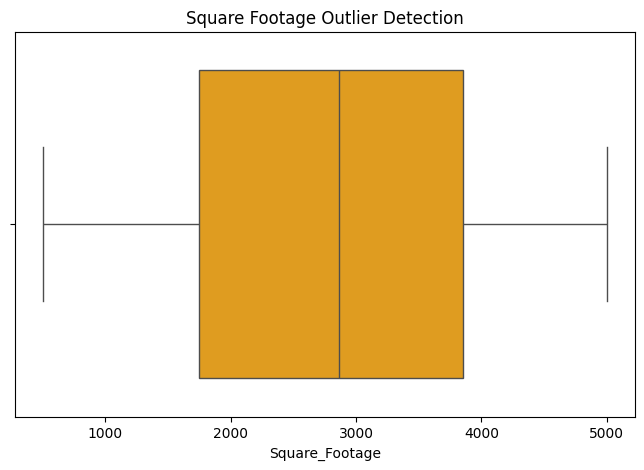

In [17]:
plt.figure(figsize=(8, 5)) 
sns.boxplot(x=df['Square_Footage'], color='orange') 
plt.title('Square Footage Outlier Detection') 
plt.show()

Some houses are extremely large or small compared to others, which may affect model performance.

**10:** How do the average numbers of bedrooms and bathrooms compare? Which is generally higher in houses?

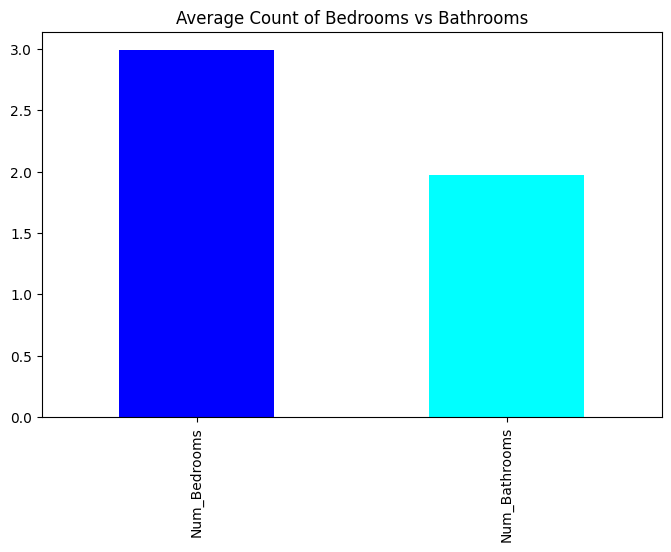

In [18]:
plt.figure(figsize=(8, 5)) 
df[['Num_Bedrooms', 'Num_Bathrooms']].mean().plot(kind='bar', color=['blue', 'cyan']) 
plt.title('Average Count of Bedrooms vs Bathrooms') 
plt.show()

Typically, houses have more bedrooms than bathrooms, which reflects common residential design.

<h2 style="font-weight:bold;">🔹 Splitting Features and Target Variable</h2>

In [19]:
X = df.drop('House_Price', axis=1) 
y = df['House_Price']

<h2 style="font-weight:bold;">🔹 Train-Test Split</h2>

In [20]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
regressor= LinearRegression() 
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = regressor.predict(X_test)

In [24]:
from sklearn import metrics
print('mean absolute error :',metrics.mean_absolute_error(y_test,y_pred)) 
print("mean squared error :",metrics.mean_squared_error(y_test,y_pred)) 
print("mean :",df['House_Price'].mean()) 
print('root mean squared error:',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

mean absolute error : 7849.86613249403
mean squared error : 98600467.10699856
mean : 618861.0186467685
root mean squared error: 9929.776790391543


In [25]:
from sklearn.metrics import r2_score 
score=r2_score(y_test,y_pred) 
print("r2 score is :",score*100,'%')

r2 score is : 99.83750828466597 %


<h2 style="font-weight:bold;">POLYNOMIAL REGRESSION</h2>

<p style="font-size:16px;">We apply Polynomial Features to capture non-linear relationships in the data.</p>

In [26]:
poly= PolynomialFeatures(degree=2) 
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [27]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred_poly = model_poly.predict(X_test_poly)

In [29]:
print("Polynomial Regression")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_poly))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_poly)))
print("R2 Score:", r2_score(y_test, y_pred_poly))

Polynomial Regression
MAE: 8073.160696282435
MSE: 105475123.43116753
RMSE: 10270.108248269224
R2 Score: 0.9982617898034094


In [30]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("RANDOM FOREST")
score=r2_score(y_test,y_pred_rf) 
print("r2 score is :",score*100,'%')

RANDOM FOREST
r2 score is : 99.1737658417723 %


In [31]:
print("MODEL COMPARISON")
print("Linear:", r2_score(y_test, y_pred)*100,'%')
print("Polynomial:", r2_score(y_test, y_pred_poly)*100,'%')
print("Random Forest:", r2_score(y_test, y_pred_rf)*100,'%')

MODEL COMPARISON
Linear: 99.83750828466597 %
Polynomial: 99.82617898034094 %
Random Forest: 99.1737658417723 %


linear regression performed best among all models due to its ability to capture complex patterns, achieving higher accuracy compared to Random Forest and Polynomial Regression.

<h2 style="font-weight:bold;">CONCLUSION</h2>

This project shows how machine learning can be used to predict housing prices using real-world features.

EDA revealed that square footage, neighborhood quality, and lot size are the most important factors influencing price. Multiple models were tested, where Linear Regression provided a strong baseline, while Polynomial Regression improved performance by capturing non-linear relationships. Random Forest also handled complex patterns effectively.

💡 Overall, the project highlights the importance of data preprocessing, feature understanding, and choosing the right model for accurate predictions.